In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from transformers import RoFormerModel, RoFormerConfig
from transformers import RobertaModel
from transformers import RobertaConfig
import os
from collections import OrderedDict
from scipy.stats import pearsonr
from matplotlib import pyplot as plt
import random
import pickle
import numpy as np
import pandas as pd
import sys
sys.path.append("/blue/juannanzhou/palash.sethi/Projects/bacteria_genome")
from tqdm import tqdm
from model_training.final_training_scripts import utils as BLM
import scipy
from torch.utils.data import DataLoader, Subset
from itertools import product
from datetime import datetime
from collections import OrderedDict
import itertools
from torch.nn import MSELoss
import scipy.stats
from torch.utils.data import Subset
from tqdm.notebook import tqdm

In [2]:
from datetime import datetime
from collections import OrderedDict


def get_model_bacpt_small(epoch=-1):
    config = RobertaConfig(
        hidden_size = 480,
        position_embedding_type = 'relative_key_query',
        token_type_embeddings = None,
        max_position_embeddings = 5000,
        return_dict = True,
        num_hidden_layers = 10,
        num_attention_heads = 5,
        attn_implementation = 'default',
        pca_dim = 480,
        pca = True,
        type_vocab_size = 1,
        tie_word_embeddings = False,
        hidden_dropout_prob = 0.1,
        hidden_act = 'gelu',
        output_hidden_states=True,
        output_attentions=True
    )

    model = BLM.BacteriaLM(config, add_pooling_layer = False)
    scaler = None
    begin_epoch = 0
    if True:
        checkpoint_path = os.path.join('/orange/juannanzhou/bacteria_genome/final_checkpoints/All_PC_sorted', 'checkpoints')
        if epoch>0:
            last_epoch = epoch
        else:
            last_epoch = BLM.get_last_epoch(checkpoint_path)

        checkpoint_path_epoch = os.path.join(checkpoint_path, 'model_' + str(last_epoch) + '.cp')
        checkpoint = torch.load(checkpoint_path_epoch, map_location='cpu')
        model_state_dict = checkpoint['model_state_dict']
        new_state_dict = OrderedDict((key.replace('module.', ''), value) for key, value in model_state_dict.items())
        model.load_state_dict(new_state_dict)
        begin_epoch = checkpoint['epoch']
        loss = checkpoint['train_loss']
        print("loaded from checkpoint:"+str(checkpoint_path_epoch))
    return model

def get_model_bacpt_large(epoch=-1):
    # Create model from config
    config = RoFormerConfig(
        hidden_size=480,
        max_position_embeddings=5000,
        num_hidden_layers=19,
        num_attention_heads=10,
        attn_implementation=None,
        pca_dim=480,
        pca=True,
        type_vocab_size=1,
        hidden_dropout_prob=0.1,
        hidden_act='gelu'
    )
    
    # Initialize a new model with random weights
    model = BLM.BacteriaLM_rope(config)
    
    # Save initial random weights for comparison
    initial_random_weights = {}
    for name, param in model.named_parameters():
        initial_random_weights[name] = param.clone().detach()
    
    scaler = None
    begin_epoch = 0
    
    # Load checkpoint
    # checkpoint_path = os.path.join('/orange/juannanzhou/bacteria_genome/final_checkpoints/RoformerContigFinal_v2_bacPT', 'checkpoints')
    checkpoint_path = os.path.join('/orange/juannanzhou/bacteria_genome/final_checkpoints/RoformerFinal_BacPT_mr_cosine_decay_40_to_1', 'checkpoints')
    
    if epoch > 0:
        last_epoch = epoch
    else:
        last_epoch = BLM.get_last_epoch(checkpoint_path)
    
    checkpoint_path_epoch = os.path.join(checkpoint_path, 'model_' + str(last_epoch) + '.cp')
    
    # Load checkpoint if it exists
    if os.path.exists(checkpoint_path_epoch):
        checkpoint = torch.load(checkpoint_path_epoch, map_location='cpu')
        model_state_dict = checkpoint['model_state_dict']
        
        # Handle distributed training model prefix if present
        new_state_dict = OrderedDict((key.replace('module.', ''), value) for key, value in model_state_dict.items())
        
        # Load state dictionary into model
        model.load_state_dict(new_state_dict)
        
        # Get checkpoint metadata
        begin_epoch = checkpoint['epoch']
        loss = checkpoint['train_loss']
        
        # Get checkpoint creation time
        creation_time = datetime.fromtimestamp(os.path.getmtime(checkpoint_path_epoch))
        
        print(f"Loaded from checkpoint: {checkpoint_path_epoch}")
        print(f"Checkpoint created on: {creation_time}")
        print(f"Epoch: {begin_epoch}, Training loss: {loss}")
        
        # Verify weights have changed after loading
        weights_changed = False
        unchanged_params = []
        
        for name, param in model.named_parameters():
            if name in initial_random_weights:
                # Check if weights are different using mean absolute difference
                diff = torch.mean(torch.abs(initial_random_weights[name] - param)).item()
                if diff > 1e-7:  # Threshold to account for floating point precision
                    weights_changed = True
                else:
                    unchanged_params.append(name)
        
        if weights_changed:
            print("Model weights successfully loaded from checkpoint (weights are different from random initialization)")
            if unchanged_params:
                print(f"Warning: {len(unchanged_params)} parameters unchanged after loading checkpoint")
                print(f"First few unchanged parameters: {unchanged_params[:5]}")
        else:
            print("WARNING: Model weights do not appear to have changed after loading checkpoint!")
    else:
        print(f"Checkpoint not found at: {checkpoint_path_epoch}")
    
    return model

In [3]:
def prepare_noise_tensors(noise_mean, noise_var, batch_size, seq_length):
    mean = torch.zeros(noise_mean.shape).cuda()
    std_dev = torch.tensor(noise_var ** 0.5).cuda()
    mean = mean.unsqueeze(0).unsqueeze(0).expand(batch_size, seq_length, -1)
    std_dev = std_dev.unsqueeze(0).unsqueeze(0).expand_as(mean)
    noise = torch.normal(mean=mean, std=std_dev).to(dtype=torch.float32)
    return noise


def create_mask_tokens(attention_mask, mask_prob):
    rand = torch.rand(attention_mask.shape).cuda()
    masked_tokens = (rand < mask_prob) & (attention_mask != 0)
    masked_tokens = torch.unsqueeze(masked_tokens, -1)
    return masked_tokens


def apply_masking(inputs_embeds, masked_tokens, noise, mask_type):
    if mask_type is not None:
        inputs_embeds = torch.where(masked_tokens, noise, inputs_embeds)
    return inputs_embeds

class ExhaustiveScaffoldDataset(Dataset):
    def __init__(self, proteome_tensor, num_scaffolds=5, max_seq_len=5000):
        assert proteome_tensor.ndim == 2
        self.proteome = proteome_tensor
        self.num_scaffolds = num_scaffolds
        self.max_seq_len = max_seq_len

        N = proteome_tensor.size(0)
        sizes = [N // num_scaffolds] * num_scaffolds
        for i in range(N % num_scaffolds):
            sizes[i] += 1
        self.scaffolds = list(torch.split(proteome_tensor, sizes))

        self.permutations = list(itertools.permutations(range(num_scaffolds)))
        self.reverse_flags = list(itertools.product([False, True], repeat=num_scaffolds))
        self.total = len(self.permutations) * len(self.reverse_flags)
        self.orig_len = proteome_tensor.size(0)

    def __len__(self):
        return self.total

    def __getitem__(self, idx):
        perm_idx = idx // len(self.reverse_flags)
        rev_idx = idx % len(self.reverse_flags)

        perm = self.permutations[perm_idx]
        rev_flags = self.reverse_flags[rev_idx]

        ordered = []
        for s in perm:
            sc = self.scaffolds[s]
            if rev_flags[s]:
                sc = torch.flip(sc, dims=[0])
            ordered.append(sc)
        emb = torch.cat(ordered, dim=0)
        assert emb.size(0) == self.proteome.size(0)

        # pad to 5k
        emb = F.pad(emb, (0, 0, 0, self.max_seq_len - emb.size(0)), value=0.0)
        return emb

def get_output_and_loss(model, inputs_embeds, attention_mask, masked_tokens, labels):
    outputs = model(attention_mask=attention_mask, inputs_embeds=inputs_embeds)
    predicted_embeds = outputs
    loss_fct = MSELoss()
    masked = masked_tokens.squeeze(-1)
    mse = loss_fct(predicted_embeds[masked], labels[masked])
    return mse

def evaluate_roberta(model, noise_mean, noise_var, test_dataloader, mask_prob,
                     fixed_mask, mask_type='random', num_scaffolds=5, max_seq_len=5000):
    model = model.cuda().eval()
    mse_results = []
    mse_original = None

    with torch.no_grad():
        for inputs_embeds, labels, attention_mask, original_length in test_dataloader:
            # slice to true proteome length
            true_len = min(5000,original_length.item())
            inputs_embeds = inputs_embeds[:, :true_len, :].squeeze(0).cuda()

            # ---- baseline (original proteome) ----
            attention_mask = torch.ones(1, max_seq_len).cuda()
            labels = F.pad(inputs_embeds, (0, 0, 0, max_seq_len - true_len), value=0.0)
            # print(labels.shape, max_seq_len, true_len)
            masked_tokens = create_mask_tokens(attention_mask, mask_prob)
            noise = prepare_noise_tensors(noise_mean, noise_var, 1, max_seq_len)
            # print(labels.shape, masked_tokens.shape, noise.shape)
            noisy_embeds = apply_masking(labels.unsqueeze(0), masked_tokens, noise, mask_type)
            mse_original = get_output_and_loss(model, noisy_embeds, attention_mask, masked_tokens, labels.unsqueeze(0))
            # print(mse_original)

            # ---- exhaustive scaffold dataset ----
            scaffold_ds = ExhaustiveScaffoldDataset(inputs_embeds, num_scaffolds=num_scaffolds, max_seq_len=max_seq_len)
            # scaffold_dl = DataLoader(scaffold_ds, batch_size=1, shuffle=False)
            n = min(100, len(scaffold_ds))
            subset_indices = random.sample(range(len(scaffold_ds)), n)
            scaffold_subset = Subset(scaffold_ds, subset_indices)

            scaffold_dl = DataLoader(scaffold_subset, batch_size=1, shuffle=False)

            for emb in tqdm(scaffold_dl, desc="Scaffold combinations", leave=False):
                emb = emb.cuda()
                labels = emb.clone()

                # attention mask = 1 until true_len, then 0 (padded)
                attention_mask = torch.cat([
                    torch.ones(1, true_len, device='cuda'),
                    torch.zeros(1, max_seq_len - true_len, device='cuda')
                ], dim=1)

                masked_tokens = create_mask_tokens(attention_mask, mask_prob)
                noise = prepare_noise_tensors(noise_mean, noise_var, 1, max_seq_len)
                noisy_embeds = apply_masking(emb, masked_tokens, noise, mask_type)
                mse_val = get_output_and_loss(model, noisy_embeds, attention_mask, masked_tokens, labels)
                mse_results.append(mse_val.item())
                # print(mse_results[-1])

    return {
        "mse_original": mse_original.item(),
        "mse_distribution": mse_results,
    }

def seed_everything(seed=42):
    """
    Seed all random number generators for reproducibility.
    
    Args:
        seed: random seed value
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # for multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
def run_scaffold_evaluation(model, full_ds, indexes=None, mask_prob=0.4, num_scaffolds=3, max_seq_len=5000, seed=42):
    """
    Run exhaustive scaffold evaluation for one or multiple proteome samples.
    
    Args:
        model: trained model
        full_ds: BLM.PCAGenomeDataset instance
        indexes: list of sample indices to evaluate; if None, randomly sample up to 5 indices
        mask_prob: masking probability
        num_scaffolds: number of scaffolds to split each proteome into
        max_seq_len: padding length (default=5000)
        
    Returns:
        results_dict: {
            index_i: {"mse_original": float, "mse_distribution": list}
        }
    """
    seed_everything(seed)
    # default random subset
    if indexes is None:
        n = min(100, len(full_ds))
        indexes = random.sample(range(len(full_ds)), n)
        print("total number of genomes ", len(indexes))

    results_dict = {}

    for idx in tqdm(indexes, desc='genomes', leave=False):
        seed_everything(seed + idx)
        sub_ds = Subset(full_ds, [idx])
        test_dataloader = DataLoader(sub_ds, batch_size=1, shuffle=False)

        res = evaluate_roberta(
            model=model,
            noise_mean=full_ds.ipca.mean_,
            noise_var=full_ds.ipca.var_,
            test_dataloader=test_dataloader,
            mask_prob=mask_prob,
            fixed_mask=False,
            mask_type='random',
            num_scaffolds=num_scaffolds,
            max_seq_len=max_seq_len
        )

        results_dict[idx] = {
            "mse_original": res["mse_original"],
            "mse_distribution": res["mse_distribution"]
        }

    return results_dict

In [ ]:
import itertools, pickle, os

id_path = '/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/data/dataset_final/test_proteins.csv'
emb_path = '/orange/juannanzhou/bacteria_genome/protein_faa_files/sorted_esm_embeds/480_dim'

full_ds = BLM.PCAGenomeDataset(
    num_samples=-1,
    max_seq_len=5000,
    id_vs_num_filepath=id_path,
    parent_directory=emb_path,
    return_original_len=True
)

model = get_model_bacpt_small()

seeds = [123]#,42, 777, 89, 142]
mask_probs = [0.1, 0.15, 0.2, 0.3, 0.4]
scaffold_counts = [2, 3, 5, 7]

save_path = (
    "/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/"
    "model_training/interpretation_tasks/scaffold_new/results/"
    "scaffold_eval_results_final_seed123_bpt_small.pkl"
)

# load existing results if present
if os.path.exists(save_path):
    with open(save_path, "rb") as f:
        all_results = pickle.load(f)
else:
    all_results = {}

# find completed seeds
completed_seeds = {k[0] for k in all_results.keys()}

for seed in tqdm(seeds, desc="seeds"):
    seed_key = f"seed_{seed}"

    if seed_key in completed_seeds:
        print(f"Skipping seed {seed} (already exists)")
        continue

    seed_results = {}

    for mask_prob in tqdm(mask_probs, desc="masks", leave=False):
        for num_scaffolds in tqdm(scaffold_counts, desc="scaffolds", leave=False):
            res = run_scaffold_evaluation(
                model=model,
                full_ds=full_ds,
                mask_prob=mask_prob,
                num_scaffolds=num_scaffolds,
                seed=seed
            )

            seed_results[(seed_key, f"mask_{mask_prob}", f"scaffolds_{num_scaffolds}")] = res

    # append results and save ONCE per seed
    all_results.update(seed_results)
    with open(save_path, "wb") as f:
        pickle.dump(all_results, f)

    completed_seeds.add(seed_key)
    print(f"Saved results for seed {seed}")

print("All done.")


/blue/juannanzhou/palash.sethi/conda/envs/torch27_complete/lib/python3.11/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.4.1.post1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/blue/juannanzhou/palash.sethi/conda/envs/torch27_complete/lib/python3.11/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator IncrementalPCA from version 1.4.1.post1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


loaded from checkpoint:/orange/juannanzhou/bacteria_genome/final_checkpoints/All_PC_sorted/checkpoints/model_1107.cp


seeds:   0%|          | 0/1 [00:00<?, ?it/s]

masks:   0%|          | 0/5 [00:00<?, ?it/s]

scaffolds:   0%|          | 0/4 [00:00<?, ?it/s]

...

Scaffold combinations:   0%|          | 0/100 [00:00<?, ?it/s]

Scaffold combinations:   0%|          | 0/100 [00:00<?, ?it/s]

Scaffold combinations:   0%|          | 0/100 [00:00<?, ?it/s]

Scaffold combinations:   0%|          | 0/100 [00:00<?, ?it/s]

Scaffold combinations:   0%|          | 0/100 [00:00<?, ?it/s]

In [1]:
# import pickle
# save_path = "/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/scaffold_new/results/scaffold_eval_results_p1.pkl"

# with open(save_path, "rb") as f:
#     all_results1 = pickle.load(f)
    
# save_path = "/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/scaffold_new/results/scaffold_eval_results_p2.pkl"

# with open(save_path, "rb") as f:
#     all_results2 = pickle.load(f)

# all_results = {}
# all_keys = set(all_results1.keys()) | set(all_results2.keys())

# for key in all_keys:
#     all_results[key] = {}
#     if key in all_results1:
#         all_results[key].update(all_results1[key])
#     if key in all_results2:
#         all_results[key].update(all_results2[key])

In [5]:
len(all_results)

20

In [1]:
import pickle
import numpy as np
from matplotlib import pyplot as plt
save_path = "/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/scaffold_new/results/scaffold_eval_results_final_seed123.pkl"

with open(save_path, "rb") as f:
    all_results_large = pickle.load(f)

In [2]:
import pickle
import numpy as np
from matplotlib import pyplot as plt
save_path = "/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/scaffold_new/results/scaffold_eval_results_final_seed123_bpt_small.pkl"

with open(save_path, "rb") as f:
    all_results_small = pickle.load(f)

In [5]:
def plot_heatmap(matrix, mask_probs, scaffold_counts, title="MSE Heatmap"):
    plt.figure(figsize=(7, 6))
    im = plt.imshow(matrix, cmap='RdBu_r', aspect='auto', vmin=0, vmax=100)
    plt.colorbar(im, label='percentile of original MSE in scrambled scaffold MSE distribution')

    plt.title(title)
    plt.xlabel("number of scaffolds")
    plt.ylabel("mask probability")

    plt.xticks(ticks=np.arange(len(scaffold_counts)), labels=scaffold_counts)
    plt.yticks(ticks=np.arange(len(mask_probs)), labels=mask_probs)

    plt.tight_layout()
    plt.show()

def get_percentile(orig_mse, mse_values):
    percentile = (np.sum(mse_values <= orig_mse) / len(mse_values)) * 100
    return percentile

percentile_dict = {}
orig_mses = []
fake_mses = []
for key in all_results:
    vals = []
    for gidx in all_results[key]:
        # print(key, gidx)
        orig_mse = all_results[key][gidx]['mse_original']
        mse_values = all_results[key][gidx]['mse_distribution']
        orig_mses.append(orig_mse)
        fake_mses.extend(mse_values)
        p = get_percentile(orig_mse, np.array(mse_values))
        vals.append(p)
    percentile_dict[key] = (np.mean(vals), np.median(vals), len(vals), vals)

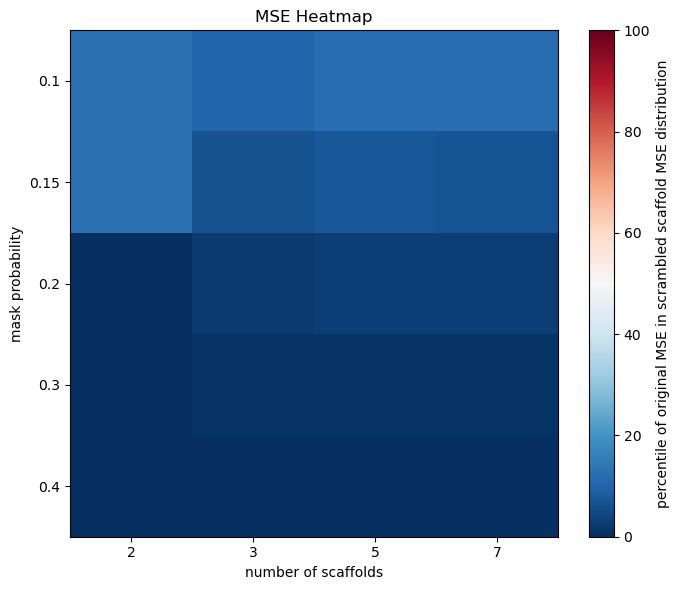

In [6]:
seeds = [123]#, 42, 777, 89, 142]
mask_probs = [0.1, 0.15, 0.2, 0.3, 0.4]
scaffold_counts = [2, 3, 5, 7]

for seed_of_interest in seeds:
    mat = np.zeros((len(mask_probs), len(scaffold_counts)))

    for key, val in percentile_dict.items():
        seed_tag, mask_tag, scaff_tag = key

        seed_val = int(seed_tag.split('_')[1])
        if seed_val != seed_of_interest:
            continue

        mask_val = float(mask_tag.split('_')[1])
        scaff_val = int(scaff_tag.split('_')[1])

        if mask_val in mask_probs and scaff_val in scaffold_counts:
            row = mask_probs.index(mask_val)
            col = scaffold_counts.index(scaff_val)
            mat[row, col] = val[1] if isinstance(val, (list, tuple)) else val

    # print(f"\nSeed {seed_of_interest}")
    # print(mat)
    plot_heatmap(mat, mask_probs, scaffold_counts)
    plt.show()


400


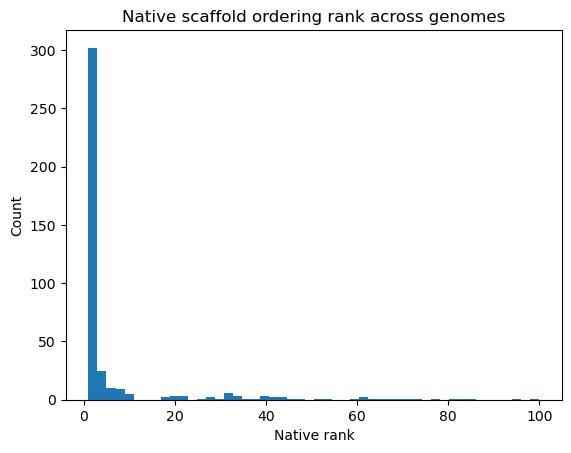

In [7]:
def plot_native_rank_hist(all_results, normalize=True):
    ranks = []

    for _, res in all_results.items():
        seed_tag, mask_tag, scaff_tag = _
        if mask_tag.split('_')[-1] == '0.4':
            for _, v in res.items():
                native = v["mse_original"]
                perms = np.array(v["mse_distribution"])
                rank = np.sum(perms < native) + 1  # 1 = best
                if normalize:
                    rank = rank / (len(perms) + 1)
                ranks.append(rank)
    print(len(ranks))

    plt.hist(ranks, bins=50)
    plt.xlabel("Native percentile rank" if normalize else "Native rank")
    plt.ylabel("Count")
    plt.title("Native scaffold ordering rank across genomes")
    plt.show()

plot_native_rank_hist(all_results, normalize=False)

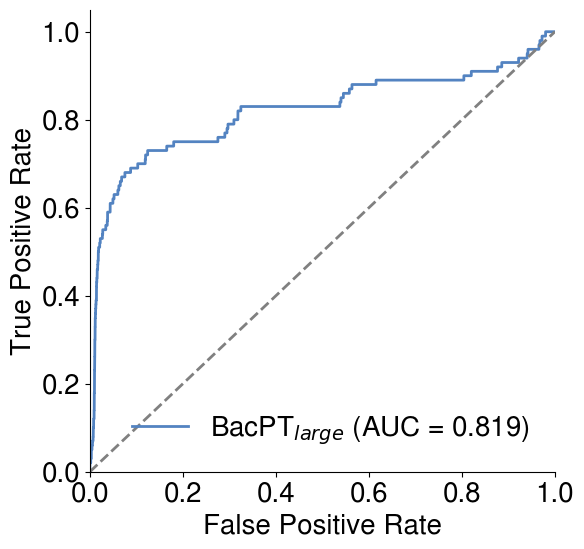

Native sequences: 400
Permuted sequences: 25600
AUC: 0.8194


In [13]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 20})
plt.rcParams['font.family'] = 'Nimbus Sans'


def plot_native_rank_auroc(all_results):
    scores = []
    labels = []
    
    for _, res in all_results.items():
        seed_tag, mask_tag, scaff_tag = _
        if mask_tag.split('_')[-1] == '0.4':
            for _, v in res.items():
                native_mse = v["mse_original"]
                perm_mses = v["mse_distribution"]
                
                # Native sequence (label = 1, score = negative MSE since lower is better)
                labels.append(1)
                scores.append(-native_mse)
                
                # Permuted sequences (label = 0)
                for perm_mse in perm_mses:
                    labels.append(0)
                    scores.append(-perm_mse)
    
    labels = np.array(labels)
    scores = np.array(scores)
    
    # Compute ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    
    # Plot
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='#5383C1', lw=2, label=f'BacPT$_{{large}}$ (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    # plt.title('ROC Curve: Identifying Native Scaffolds')
    plt.legend(loc="lower right", frameon=False)
    for spine in plt.gca().spines.values():
        spine.set_visible(False)
    plt.gca().spines['left'].set_visible(True)
    plt.gca().spines['bottom'].set_visible(True)
    # plt.grid(alpha=0.3)
    plt.show()
    
    print(f"Native sequences: {np.sum(labels == 1)}")
    print(f"Permuted sequences: {np.sum(labels == 0)}")
    print(f"AUC: {roc_auc:.4f}")

plot_native_rank_auroc(all_results)

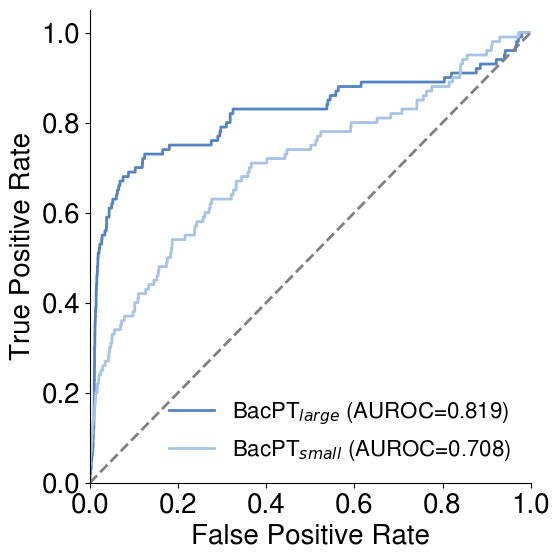

[large] Native: 400 | Permuted: 25600 | AUROC: 0.8194
[small] Native: 400 | Permuted: 25600 | AUROC: 0.7085


In [3]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({'font.size': 20})
plt.rcParams['font.family'] = 'Nimbus Sans'

big_model_color = '#5383C1'
small_model_color = '#A7C3E5'

def _scores_labels(all_results):
    scores, labels = [], []
    for key, res in all_results.items():
        seed_tag, mask_tag, scaff_tag = key
        if mask_tag.split('_')[-1] == '0.4':
            for _, v in res.items():
                native_mse = v["mse_original"]
                perm_mses = v["mse_distribution"]

                labels.append(1)
                scores.append(-native_mse)

                for perm_mse in perm_mses:
                    labels.append(0)
                    scores.append(-perm_mse)

    return np.array(scores), np.array(labels)

def plot_native_rank_auroc_both(all_results_large, all_results_small):
    scores_L, labels_L = _scores_labels(all_results_large)
    scores_S, labels_S = _scores_labels(all_results_small)

    fpr_L, tpr_L, _ = roc_curve(labels_L, scores_L)
    auc_L = auc(fpr_L, tpr_L)

    fpr_S, tpr_S, _ = roc_curve(labels_S, scores_S)
    auc_S = auc(fpr_S, tpr_S)

    fig, ax = plt.subplots(figsize=(6, 6))

    ax.plot(fpr_L, tpr_L, color=big_model_color, lw=2,
            label=rf'BacPT$_{{large}}$ (AUROC={auc_L:.3f})')
    ax.plot(fpr_S, tpr_S, color=small_model_color, lw=2,
            label=rf'BacPT$_{{small}}$ (AUROC={auc_S:.3f})')

    ax.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.05)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')

    ax.spines[['top', 'right']].set_visible(False)

    ax.legend(loc="lower right", frameon=False, fontsize=16, handlelength=2)

    plt.tight_layout()
    # plt.savefig("/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/results/figures/figures_v2/scaffold_auroc.svg", dpi=300, bbox_inches="tight")
    # plt.savefig("/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/results/figures/figures_v2/scaffold_auroc.pdf", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"[large] Native: {np.sum(labels_L==1)} | Permuted: {np.sum(labels_L==0)} | AUROC: {auc_L:.4f}")
    print(f"[small] Native: {np.sum(labels_S==1)} | Permuted: {np.sum(labels_S==0)} | AUROC: {auc_S:.4f}")

# usage:
plot_native_rank_auroc_both(all_results_large, all_results_small)


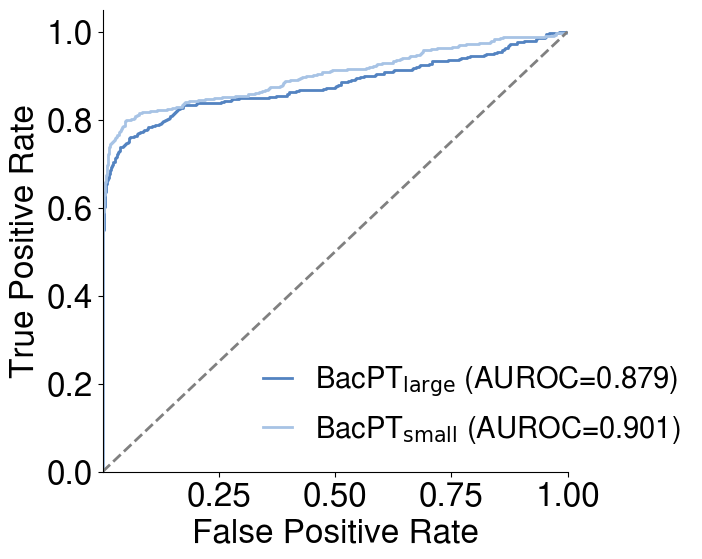

[large] Native: 400 | Permuted: 25600 | AUROC: 0.8788
[small] Native: 400 | Permuted: 25600 | AUROC: 0.9012


In [28]:
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt


plt.rcParams.update({'font.size': 24})
plt.rcParams['font.family'] = 'Nimbus Sans'

big_model_color = '#5383C1'
small_model_color = '#A7C3E5'

def _zscores_labels(all_results, mask_keep="0.4"):
    scores, labels = [], []
    for key, res in all_results.items():
        seed_tag, mask_tag, scaff_tag = key
        if mask_tag.split('_')[-1] != mask_keep:
            continue

        for _, v in res.items():
            native = v["mse_original"]
            perms = np.asarray(v["mse_distribution"], dtype=float)

            mu = perms.mean()
            sigma = perms.std()
            if sigma == 0 or np.isnan(sigma):
                continue

            z_native = (native - mu) / sigma
            z_perms = (perms - mu) / sigma

            labels.append(1)
            scores.append(-z_native)     # higher = more native (lower MSE)

            labels.extend([0] * len(z_perms))
            scores.extend((-z_perms).tolist())

    return np.asarray(scores), np.asarray(labels)

def plot_native_rank_auroc_both_zscore(all_results_large, all_results_small):
    scores_L, labels_L = _zscores_labels(all_results_large)
    scores_S, labels_S = _zscores_labels(all_results_small)

    fpr_L, tpr_L, _ = roc_curve(labels_L, scores_L)
    auc_L = auc(fpr_L, tpr_L)

    fpr_S, tpr_S, _ = roc_curve(labels_S, scores_S)
    auc_S = auc(fpr_S, tpr_S)

    fig, ax = plt.subplots(figsize=(6, 6))

    ax.plot(fpr_L, tpr_L, color=big_model_color, lw=2,
            label=rf'BacPT$_{{\mathrm{{large}}}}$ (AUROC={auc_L:.3f})')
    ax.plot(fpr_S, tpr_S, color=small_model_color, lw=2,
            label=rf'BacPT$_{{\mathrm{{small}}}}$ (AUROC={auc_S:.3f})')

    ax.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.05)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')

    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xticks([t for t in ax.get_xticks() if t != 0])
    ax.legend(loc="lower right", frameon=False, fontsize=21, handlelength=1, bbox_to_anchor=(1.3, 0))

    # plt.tight_layout()
    plt.savefig("/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/results/figures/figures_v2/scaffold_zscore_auroc.svg", dpi=300, bbox_inches="tight")
    plt.savefig("/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/results/figures/figures_v2/scaffold_score_auroc.pdf", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"[large] Native: {np.sum(labels_L==1)} | Permuted: {np.sum(labels_L==0)} | AUROC: {auc_L:.4f}")
    print(f"[small] Native: {np.sum(labels_S==1)} | Permuted: {np.sum(labels_S==0)} | AUROC: {auc_S:.4f}")

# usage:
plot_native_rank_auroc_both_zscore(all_results_large, all_results_small)


100


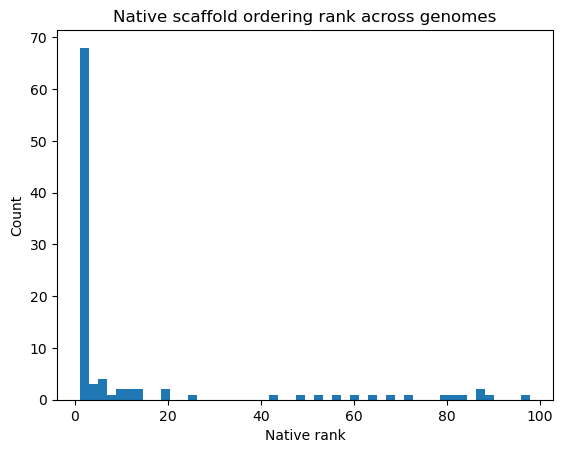

In [18]:
def plot_native_rank_hist(all_results, normalize=True):
    ranks = []

    for _, res in all_results.items():
        seed_tag, mask_tag, scaff_tag = _
        if mask_tag.split('_')[-1] == '0.4' and scaff_tag.split('_')[-1] == '7':
            for _, v in res.items():
                native = v["mse_original"]
                perms = np.array(v["mse_distribution"])
                rank = np.sum(perms < native) + 1  # 1 = best
                if normalize:
                    rank = rank / (len(perms) + 1)
                ranks.append(rank)
        # print(scaff_tag)
    print(len(ranks))

    plt.hist(ranks, bins=50)
    plt.xlabel("Native percentile rank" if normalize else "Native rank")
    plt.ylabel("Count")
    plt.title("Native scaffold ordering rank across genomes")
    plt.show()

plot_native_rank_hist(all_results, normalize=False)

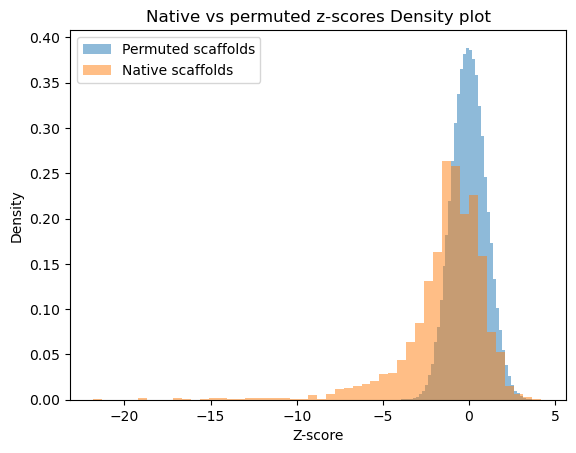

In [19]:
def plot_native_zscore_hist(all_results):
    z_native = []
    z_shuffled = []

    for _, res in all_results.items():
        for _, v in res.items():
            if mask_tag.split('_')[-1] == '0.4' and scaff_tag.split('_')[-1] == '7':
                native = v["mse_original"]
                perms = np.array(v["mse_distribution"])
                mu = perms.mean()
                sigma = perms.std()
                if sigma > 0:
                    z_native.append((native - mu) / sigma)
                    z_shuffled.extend((perms - mu) / sigma)
    
    # stat, pval = wilcoxon(z_native, alternative="less")
    plt.hist(z_shuffled, bins=50, alpha=0.5, label="Permuted scaffolds", density=True)
    plt.hist(z_native, bins=50, alpha=0.5, label="Native scaffolds", density=True)
    plt.xlabel("Z-score")
    plt.ylabel("Density")
    plt.legend()
    plt.title(f"Native vs permuted z-scores Density plot")
    plt.show()

plot_native_zscore_hist(all_results)

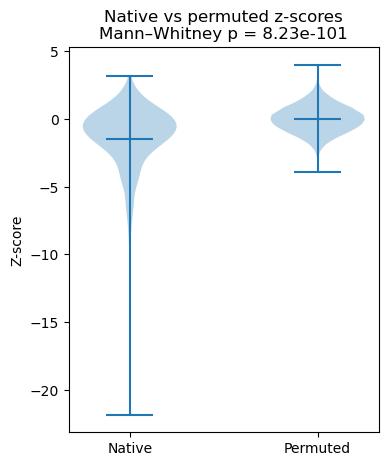

8.22542724890248e-101

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

def plot_native_zscore_violin(all_results):
    z_native = []
    z_shuffled = []

    for _, res in all_results.items():
        for _, v in res.items():
            native = v["mse_original"]
            perms = np.array(v["mse_distribution"])
            mu = perms.mean()
            sigma = perms.std()
            if sigma > 0:
                z_native.append((native - mu) / sigma)
                z_shuffled.extend((perms - mu) / sigma)

    # statistical test
    stat, pval = mannwhitneyu(z_native, z_shuffled, alternative="less")

    plt.figure(figsize=(4, 5))
    plt.violinplot([z_native, z_shuffled], showmeans=True)
    plt.xticks([1, 2], ["Native", "Permuted"])
    plt.ylabel("Z-score")
    plt.title(f"Native vs permuted z-scores\nMann–Whitney p = {pval:.2e}")
    plt.show()

    return pval

plot_native_zscore_violin(all_results)

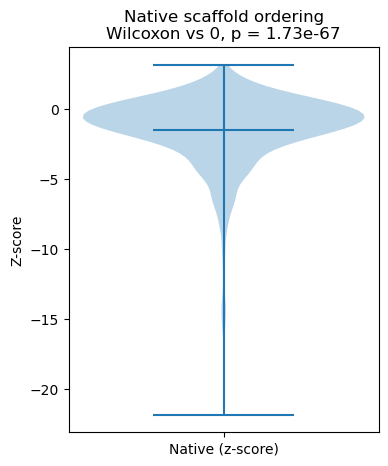

1.7256380857364044e-67

In [39]:
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
import numpy as np

def plot_native_zscore_single_violin(all_results):
    z_native = []

    for _, res in all_results.items():
        for _, v in res.items():
            native = v["mse_original"]
            perms = np.array(v["mse_distribution"])
            mu = perms.mean()
            sigma = perms.std()
            if sigma > 0:
                z_native.append((native - mu) / sigma)

    z_native = np.array(z_native)

    stat, pval = wilcoxon(z_native, alternative="less")

    plt.figure(figsize=(4, 5))
    plt.violinplot(z_native, showmeans=True)
    plt.xticks([1], ["Native (z-score)"])
    plt.ylabel("Z-score")
    plt.title(f"Native scaffold ordering\nWilcoxon vs 0, p = {pval:.2e}")
    plt.show()

    return pval


plot_native_zscore_single_violin(all_results)

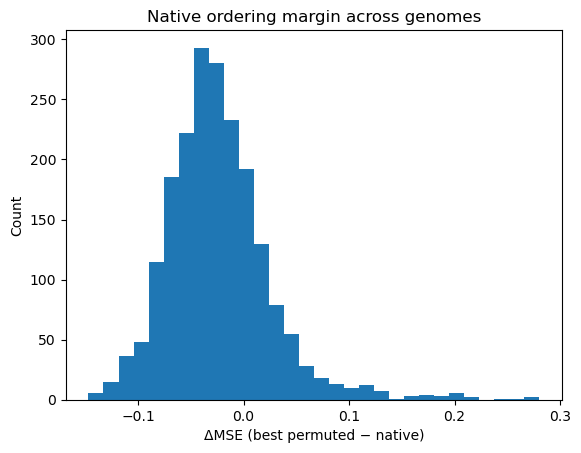

In [14]:
def plot_native_delta_hist(all_results):
    deltas = []

    for _, res in all_results.items():
        for _, v in res.items():
            native = v["mse_original"]
            best_perm = np.min(v["mse_distribution"])
            deltas.append(best_perm - native)

    plt.hist(deltas, bins=30)
    plt.xlabel("ΔMSE (best permuted − native)")
    plt.ylabel("Count")
    plt.title("Native ordering margin across genomes")
    plt.show()

plot_native_delta_hist(all_results)